# I. POWER SCALING

In [1]:
import camb
import matplotlib.pyplot as plt
import numpy as np
from camb import model
from scipy.interpolate import CubicSpline

In [2]:
pars = camb.CAMBparams()
pars = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, lmax=3000
)
pars.set_matter_power(redshifts=[0.0], kmax=200.0, nonlinear=False)
results = camb.get_results(pars)
k, z, Pk = results.get_matter_power_spectrum(
    minkh=1e-4, maxkh=100.0, npoints=500, var1=model.Transfer_tot, var2=model.Transfer_tot
)

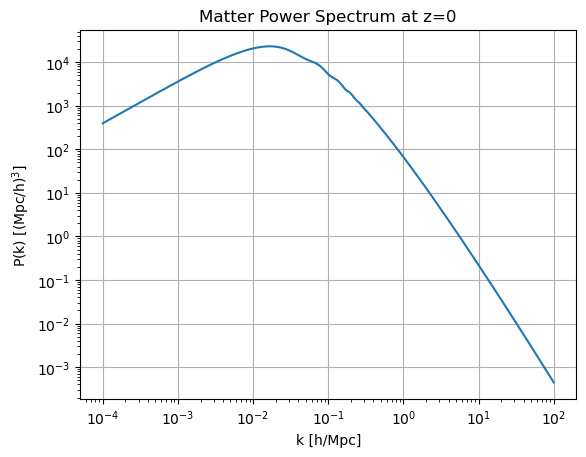

In [5]:
plt.figure()
plt.loglog(k, Pk[0, :])
plt.xlabel('k [h/Mpc]')
plt.ylabel('P(k) [(Mpc/h)$^3$]')
plt.title('Matter Power Spectrum at z=0')
plt.grid(True)
plt.show()

The matter power spectrum, $P(k)$, quantifies the amplitude of density fluctuations in the universe as a function of the comoving scale $k$. The plot exhibits three distinct behaviors, perfectly consistent with $\Lambda$ CDM cosmology:

- **Large scales** ($k \ll 10^{-2} \ h/\text{Mpc}$): The spectrum grows as $P(k) \propto k^{n_s}$ with $n_s \simeq 1$. This represents the primordial inflationary shape, which has remained largely unaffected by gravitational evolution.

- **Turnover** ($k \sim 10^{-2} \ h/\text{Mpc}$): A turnover (peak in power) is observed around this scale. It corresponds to the scale that entered the horizon during the radiation-dominated era, an epoch where the gravitational growth of perturbations was initially suppressed.

- **Small scales** ($k \gg 0.1 \ h/\text{Mpc}$): The spectrum decays rapidly, following the linear analytical relationship $P(k) \propto k^{n_s-4} \approx k^{-3}$, which is characteristic of gravitational growth in the matter-dominated regime.

Additionally, slight oscillations are visible in the intermediate region. These are caused by Baryon Acoustic Oscillations (BAO), a fossil imprint of the primordial photon-baryon plasma.

In [6]:
# Logaritms of P and k
logp = np.log10(Pk[0, :])
logk = np.log10(k)
# Building cubic spline interpolation
spline = CubicSpline(logk, logp)
# First derivative
n_eff = spline(logk, 1)

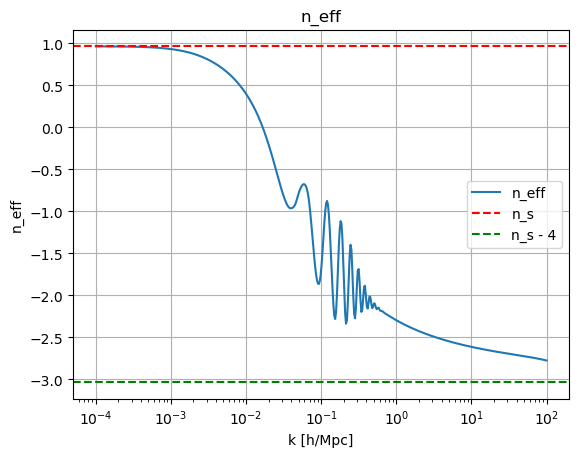

In [9]:
# Plot of n_eff
plt.figure()
plt.semilogx(k, n_eff, label='n_eff')

ns = pars.InitPower.ns
plt.axhline(y=ns, color='red', linestyle='--', label='n_s')
plt.axhline(y=ns - 4.0, color='green', linestyle='--', label='n_s - 4')
plt.legend()

plt.xlabel('k [h/Mpc]')
plt.ylabel('n_eff')
plt.title('n_eff')
plt.grid(True)

The effective spectral index, $n_{\rm eff}(k) \equiv \frac{d \ln P}{d \ln k}$, describes the local slope of the matter power spectrum. The distinct regimes predicted by $\Lambda$ CDM cosmology can be clearly identified:

- **Large Scales ($k \ll 10^{-2} \ h/\text{Mpc}$)**: The index is $n_{\rm eff} \simeq +1$, consistent with the primordial inflationary spectrum, $P(k) \propto k^{n_s}$, with $n_s \approx 1$.Transition Region ($k \sim k_{\rm eq}$): The index drops rapidly. This occurs because perturbations entered the horizon during the radiation-dominated era, temporarily suppressing their gravitational growth.

- **Intermediate Scales**: Oscillations are visible due to Baryon Acoustic Oscillations (BAO), the fossil imprint of baryon-photon acoustic waves in the primordial plasma.

- **Small Scales ($k \gg 1 \ h/\text{Mpc}$)**: The index approaches $n_{\rm eff} \to -3$, in agreement with the linear asymptotic limit, $P(k) \propto k^{n_s - 4} \approx k^{-3}$, which is characteristic of collisionless cold dark matter in the matter-dominated regime.

The comoving horizon scale at matter-radiation equality is given by:
$$k_{eq} = a_{eq} H(a_{eq})$$

To find the scale factor at equality ($a_{eq}$), we equate the energy densities:
$$\rho_m(a_{eq}) = \rho_r(a_{eq}) \implies \Omega_m a_{eq}^{-3} = \Omega_r a_{eq}^{-4} \implies a_{eq} = \frac{\Omega_r}{\Omega_m}$$

To find the Hubble parameter at equality ($H(a_{eq})$), we use the Friedmann equation, which at this epoch becomes:
$$H(a_{eq})^2 \approx H_0^2 \left[2 \Omega_r a_{eq}^{-4}\right]$$

Substituting these terms, we find that:
$$k_{eq} \propto \frac{H_0 \Omega_m}{\sqrt{\Omega_r}}$$

The formula in the code represents this exact derivation, but expressed using the physical densities ($\Omega h^2$) that CAMB utilizes:

- k_eq = 7.46e-2 * (om_m * h2) * (Tcmb/2.7)(-2)

- om_m * h2 ($\Omega_m h^2$): This is the total physical matter density.
It is the primary term that dictates when matter-radiation equality occurs.

- 7.46e-2: This numerical prefactor groups together all the relevant physical constants (such as the speed of light $c$, $H_0$ expressed in $100 \text{ km/s/Mpc}$, and $\sqrt{2}$) as well as the radiation density ($\Omega_r h^2$). 
The radiation density is not a free parameter; rather, it is fixed by the CMB temperature ($T_{cmb}$) and the effective number of relativistic neutrino species.

- (Tcmb/2.7)(-2): This acts as a scaling correction. The prefactor 7.46e-2 was calculated assuming a reference baseline of $T_{cmb} = 2.7 \text{ K}$. Because $k_{eq} \propto 1/\sqrt{\Omega_r h^2}$ and $\Omega_r h^2 \propto T_{cmb}^4$, it mathematically follows that $k_{eq} \propto 1/T_{cmb}^2$ (or $T_{cmb}^{-2}$). This term correctly adjusts the outcome if a slightly different $T_{cmb}$ value is specified in the code.

In [7]:
# Analitic k_eq
h = pars.H0/100.0
om_m = (pars.ombh2 + pars.omch2 + pars.omnuh2)/(h**2)
Tcmb = 2.7255
k_eq = 7.46e-2 * (om_m * h**2) * (Tcmb/2.7)**(-2) # [1/Mpc]
k_eq_h = k_eq / h # [h/Mpc]

$P_{\mathcal{R}}(k) = A_s \left( \frac{k}{k_{\text{pivot}}} \right)^{n_s - 1}$

In [8]:
ns = pars.InitPower.ns
def powerlaw(k, pivot, slope, P_at_pivot):
    # Gives A k^slope with A choosen to equal P_at_pivot in pivot
    A = P_at_pivot / (pivot**slope)
    return A * k**slope

In [8]:
# Choose two distant pivot from BAO and turnover
kL = 5e-4     # big scale
kS = 20.0     # small scale, well beyond the BAO
# Take the value of P(k) for match (interpolating log-log )
P = 10**(logp)
PL = 10**(CubicSpline(logk, logp)(np.log(kL)))
PS = 10**(CubicSpline(logk, logp)(np.log(kS)))

P_large  = powerlaw(k, kL,  ns,     PL)      # ~ k^{ns}
P_small  = powerlaw(k, kS,  ns-4.0, PS)      # ~ k^{ns-4} Meszaros effect

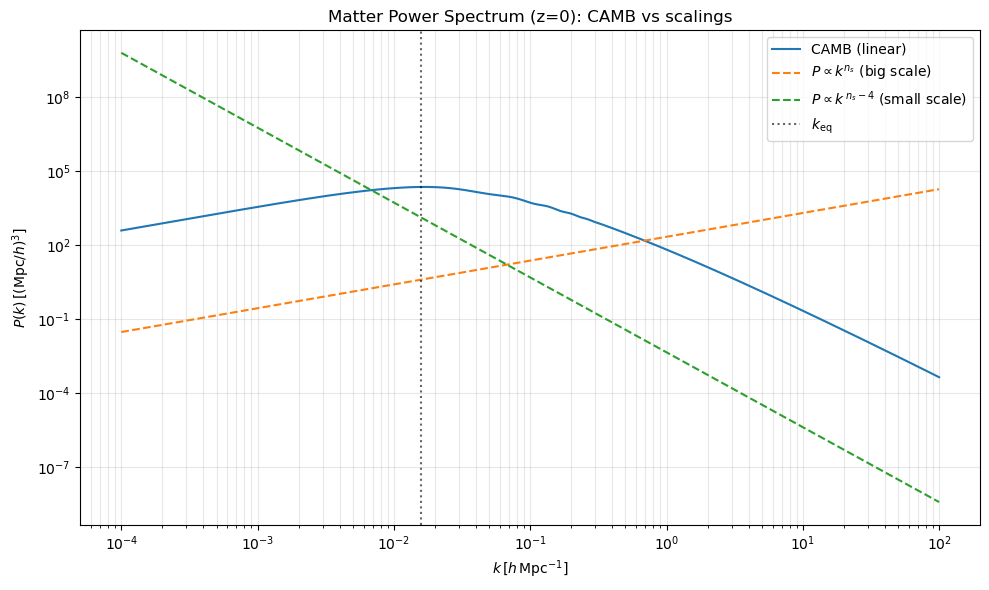

In [9]:
#  Plot P(k) con scaling e k_eq
plt.figure(figsize=(10,6))
plt.semilogx(k, P, label='CAMB (linear)')
plt.loglog(k, P_large, '--', label=r'$P \propto k^{n_s}$ (big scale)')
plt.loglog(k, P_small, '--', label=r'$P \propto k^{\,n_s-4}$ (small scale)')
plt.axvline(k_eq_h, color='k', ls=':', alpha=0.6, label=r'$k_{\rm eq}$')
plt.xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k)\,[(\mathrm{Mpc}/h)^3]$')
plt.title('Matter Power Spectrum (z=0): CAMB vs scalings')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The plot compares the linear matter power spectrum calculated with CAMB (blue curve) against the asymptotic analytical laws predicted by $\Lambda$ CDM cosmology.

- **Large Scales** ($k \ll k_{\rm eq}$): The spectrum follows $P(k) \propto k^{n_s}$ (orange line), reflecting the primordial inflationary shape. These scales entered the horizon after matter-radiation equality, meaning the universe was already matter-dominated (MD). Because they entered during a pressureless era, their growth was never suppressed, and they simply underwent standard gravitational growth.

- **Equality Scale** ($k \sim k_{\rm eq}$, dashed vertical line): The turnover is observed here. This peak is due to modes entering the horizon during the radiation-dominated era, where the gravitational growth of perturbations was temporarily suppressed.

- **Small Scales** ($k \gg k_{\rm eq}$): The spectrum approaches the asymptotic limit $P(k) \propto k^{n_s - 4} \approx k^{-3}$ (green line), in agreement with the linear gravitational growth of collisionless cold dark matter.

- **Intermediate Region**: Oscillations are visible due to Baryon Acoustic Oscillations (BAO), the fossil imprint of baryon-photon acoustics in the primordial plasma.

**Detailed Curve Breakdown**

- **Orange Curve (Large Scales)**: $P(k) \propto k^{n_s}$
This dashed line describes the scaling of the power spectrum on very large scales, $k \ll k_{eq}$.
These fluctuations entered the cosmological horizon after matter-radiation equality, during the matter-dominated (MD) era. In this regime, the pressure of the primordial plasma is negligible. Gravity dominates unopposed, and dark matter fluctuations were able to grow linearly from the exact moment they entered the horizon, without experiencing any suppression. Therefore, the shape of the power spectrum on these scales today faithfully traces the pure primordial spectrum generated by inflation: $P(k) \propto k^{n_s}$.

- **Green Curve (Small Scales)**: $P(k) \propto k^{n_s-4}$
This line describes the asymptotic behavior for fluctuations on very small scales, $k \gg k_{eq}$.
These fluctuations entered the horizon prior to equality, while the universe was still radiation-dominated (RD). During that era, the dominant gravitational source was radiation, which could not collapse due to its enormous internal pressure. The gravitational potential $\Phi$ decayed rapidly, and the growth of dark matter fluctuations (which do not experience this pressure) was effectively "frozen" or stalled, growing only very slowly (logarithmically).

Because these fluctuations spent a significant portion of the universe's history in this stalled state before being allowed to grow freely (which only occurred after the onset of the MD era), their amplitude today is heavily suppressed compared to the larger scales. This suppression is encoded in the transfer function squared, $T(k)^2 \propto k^{-4}$, leading to the final scaling: $P(k) \propto k^{n_s} k^{-4} = k^{n_s-4}$.

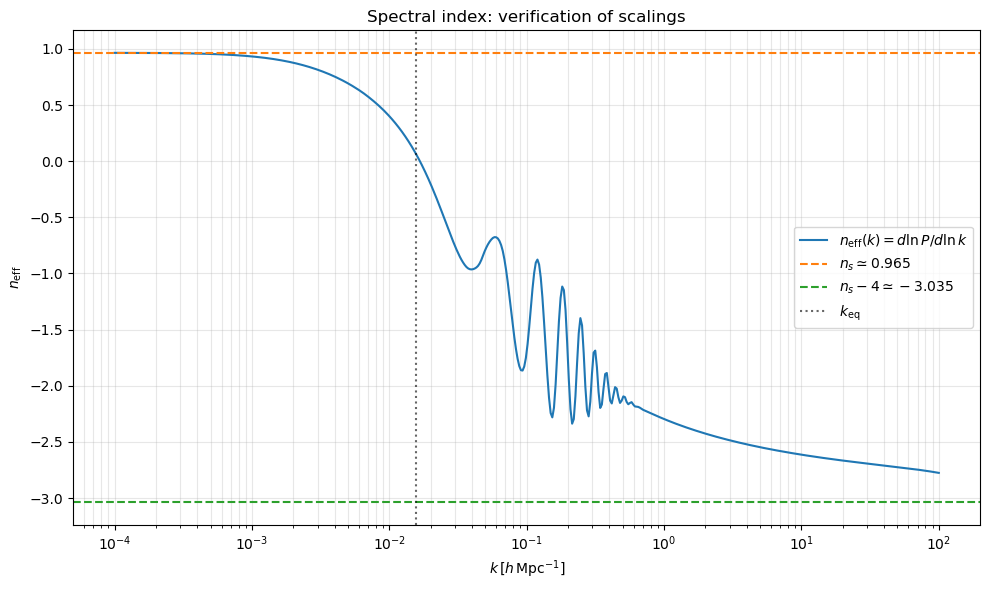

In [10]:
# Plot n_eff with guidelines for scalings and k_eq 
plt.figure(figsize=(10,6))
plt.semilogx(k, n_eff, label=r'$n_{\rm eff}(k)=d\ln P / d\ln k$')
plt.axhline(ns,     color='C1', ls='--', label=rf'$n_s \simeq {ns:.3f}$')
plt.axhline(ns-4.0, color='C2', ls='--', label=rf'$n_s-4 \simeq {ns-4.0:.3f}$')
plt.axvline(k_eq_h, color='k', ls=':', alpha=0.6, label=r'$k_{\rm eq}$')
plt.xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
plt.ylabel(r'$n_{\rm eff}$')
plt.title('Spectral index: verification of scalings')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The effective spectral index, $n_{\rm eff}(k) = \frac{d \ln P}{d \ln k}$, represents the local slope of the power spectrum as a function of the comoving scale $k$. The three distinct regimes predicted by $\Lambda$ CDM cosmology can be clearly identified:

- **Large Scales** ($k \ll k_{\rm eq}$): $n_{\rm eff} \approx +1$, in agreement with the primordial inflationary shape $P(k) \propto k^{n_s}$ (super-horizon modes).

- **Equality Region** ($k \sim k_{\rm eq}$, vertical dashed line): The index drops rapidly, marking the horizon entry of perturbations during the radiation-dominated era, where gravitational growth is suppressed.

- **Intermediate Region**: Oscillations are visible due to Baryon Acoustic Oscillations (BAO), the fossil imprint of baryon-photon acoustics in the primordial plasma.

- **Small Scales** ($k \gg 1 \ h/\text{Mpc}$): $n_{\rm eff} \to -3$, in agreement with the linear asymptotic limit $P(k) \propto k^{n_s - 4} \approx k^{-3}$, which is characteristic of collisionless Cold Dark Matter (CDM) in the matter-dominated regime.